In [201]:
pip install lightgbm


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [202]:
pip install catboost


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [203]:
import pandas as pd
import numpy as np
import joblib
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
#from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import yaml
import os
import logging
from contextlib import nullcontext
import matplotlib.pyplot as plt
import lightgbm as lgb
from catboost import CatBoostRegressor
import xgboost as xgb
from sklearn.linear_model import LinearRegression

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()

mlflow_tracking_uri = 'http://127.0.0.1:5000/'  

In [204]:
# Load dataset
train_df = pd.read_csv('train_final.csv')
test_df = pd.read_csv('test_final.csv')

In [205]:
# # Viết code loại bỏ những cột sau: Month, IsWeekend,is_holiday
# columns_to_drop = ['Month', 'IsWeekend', 'is_holiday']
# train_df = train_df.drop(columns=columns_to_drop, errors='ignore')
# test_df = test_df.drop(columns=columns_to_drop, errors='ignore')
# Kiểm tra lại số cột còn lại
print("Số cột còn lại trong train_df:", train_df.shape[1])
print("Số cột còn lại trong test_df:", test_df.shape[1]) 

Số cột còn lại trong train_df: 17
Số cột còn lại trong test_df: 17


In [206]:
# Split train_df into training and validation sets based on Year and WeekOfYear
val_condition = (train_df['Year'] == 2015) & (train_df['WeekOfYear'] >= 26)

train_set = train_df[~val_condition].copy()
val_set = train_df[val_condition].copy()

In [207]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 844338 entries, 0 to 844337
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Store                    844338 non-null  int64  
 1   DayOfWeek                844338 non-null  int64  
 2   Promo                    844338 non-null  int64  
 3   StateHoliday             844338 non-null  int64  
 4   SchoolHoliday            844338 non-null  int64  
 5   StoreType                844338 non-null  int64  
 6   Assortment               844338 non-null  int64  
 7   Promo2                   844338 non-null  int64  
 8   CompetitionDistance_log  844338 non-null  float64
 9   Sales_log                844338 non-null  float64
 10  Year                     844338 non-null  int64  
 11  Month                    844338 non-null  int64  
 12  Day                      844338 non-null  int64  
 13  WeekOfYear               844338 non-null  int64  
 14  Prom

In [208]:
# 6 tuần cuối: Tuần 26, 27, 28, 29, 30, 31 của năm 2015
val_condition = (train_df['Year'] == 2015) & (train_df['WeekOfYear'] >= 26)

train_set = train_df[~val_condition].copy()
val_set = train_df[val_condition].copy()

In [209]:
val_set.info()    

<class 'pandas.core.frame.DataFrame'>
Index: 39136 entries, 0 to 39135
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Store                    39136 non-null  int64  
 1   DayOfWeek                39136 non-null  int64  
 2   Promo                    39136 non-null  int64  
 3   StateHoliday             39136 non-null  int64  
 4   SchoolHoliday            39136 non-null  int64  
 5   StoreType                39136 non-null  int64  
 6   Assortment               39136 non-null  int64  
 7   Promo2                   39136 non-null  int64  
 8   CompetitionDistance_log  39136 non-null  float64
 9   Sales_log                39136 non-null  float64
 10  Year                     39136 non-null  int64  
 11  Month                    39136 non-null  int64  
 12  Day                      39136 non-null  int64  
 13  WeekOfYear               39136 non-null  int64  
 14  Promo2Open_Month         39

# More Feature engineering

In [210]:
# ==========================================
# 1. TÍNH TOÁN KINH NGHIỆM (CHỈ TỪ TRAIN_SET)
# ==========================================
# Tính trung bình Sales_log theo Store, Thứ và Promo
store_dw_promo_avg = train_set.groupby(['Store', 'DayOfWeek', 'Promo'])['Sales_log'].mean().reset_index()
store_dw_promo_avg.rename(columns={'Sales_log': 'Store_DW_Promo_Avg'}, inplace=True)

# Tính trung bình Sales_log theo Tháng (Neo mùa vụ)
month_avg = train_set.groupby('Month')['Sales_log'].mean().reset_index()
month_avg.rename(columns={'Sales_log': 'Month_Avg_Sales'}, inplace=True)

# ==========================================
# 2. RẢI FEATURE SANG 3 TẬP (MERGE)
# ==========================================

# -- Cho TRAIN_SET --
train_set = train_set.merge(store_dw_promo_avg, on=['Store', 'DayOfWeek', 'Promo'], how='left')
train_set = train_set.merge(month_avg, on='Month', how='left')

# -- Cho VAL_SET --
val_set = val_set.merge(store_dw_promo_avg, on=['Store', 'DayOfWeek', 'Promo'], how='left')
val_set = val_set.merge(month_avg, on='Month', how='left')

# -- Cho TEST_DF --
test_df = test_df.merge(store_dw_promo_avg, on=['Store', 'DayOfWeek', 'Promo'], how='left')
test_df = test_df.merge(month_avg, on='Month', how='left')

# ==========================================
# 3. XỬ LÝ NaN (DÙNG TRUNG BÌNH CỦA TRAIN_SET)
# ==========================================
# Lấy trung bình tổng của train_set làm "phao cứu sinh"
global_mean_train = train_set['Sales_log'].mean()

# Điền cho Val và Test những chỗ bị hụt kinh nghiệm
val_set['Store_DW_Promo_Avg'] = val_set['Store_DW_Promo_Avg'].fillna(global_mean_train)
val_set['Month_Avg_Sales'] = val_set['Month_Avg_Sales'].fillna(global_mean_train)

test_df['Store_DW_Promo_Avg'] = test_df['Store_DW_Promo_Avg'].fillna(global_mean_train)
test_df['Month_Avg_Sales'] = test_df['Month_Avg_Sales'].fillna(global_mean_train)

# ==========================================
# 4. ĐỒNG BỘ CỘT (QUAN TRỌNG CHO XGBOOST)
# ==========================================
# Đảm bảo test_df và val_set có thứ tự cột y hệt train_set (trừ cột Sales/Sales_log)
feature_cols = [c for c in train_set.columns if c not in ['Sales', 'Sales_log']]

# Nếu test_df có cột 'Id', giữ lại để nộp bài nhưng không đưa vào train
val_set = val_set[feature_cols + ['Sales_log']]
# test_df thường có cột Id, ta sắp xếp các cột feature còn lại theo đúng train_set
test_df_features = test_df[feature_cols] 

print("✅ Đã xử lý xong train_set, val_set và test_df!")
print(f"Feature mới đã nạp: {train_set.columns[-2:].tolist()}")

✅ Đã xử lý xong train_set, val_set và test_df!
Feature mới đã nạp: ['Store_DW_Promo_Avg', 'Month_Avg_Sales']


In [211]:
#drop Promo2 ở 3 tập
train_set = train_set.drop(columns=['Promo2',], errors='ignore')
val_set = val_set.drop(columns=['Promo2'], errors='ignore')
test_df = test_df.drop(columns=['Promo2'], errors='ignore')

In [212]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 805202 entries, 0 to 805201
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Store                    805202 non-null  int64  
 1   DayOfWeek                805202 non-null  int64  
 2   Promo                    805202 non-null  int64  
 3   StateHoliday             805202 non-null  int64  
 4   SchoolHoliday            805202 non-null  int64  
 5   StoreType                805202 non-null  int64  
 6   Assortment               805202 non-null  int64  
 7   CompetitionDistance_log  805202 non-null  float64
 8   Sales_log                805202 non-null  float64
 9   Year                     805202 non-null  int64  
 10  Month                    805202 non-null  int64  
 11  Day                      805202 non-null  int64  
 12  WeekOfYear               805202 non-null  int64  
 13  Promo2Open_Month         805202 non-null  float64
 14  Comp

In [213]:
# # --- 1. TÍNH TOÁN THỐNG KÊ (CHỈ TRÊN TRAIN_SET) ---

# # # A. Store Median (Đã có của bạn)
# # store_median = train_set.groupby('Store')['Sales'].median().to_dict()

# # # B. Store + DayOfWeek Median ("Tính cách" theo thứ)
# # store_dow_stats = train_set.groupby(['Store', 'DayOfWeek'])['Sales'].median().reset_index()
# # store_dow_stats.rename(columns={'Sales': 'Store_DoW_Median'}, inplace=True)

# # # C. Promo Lift (Độ hiệu quả của khuyến mãi cho từng Store)
# # # Tính median khi có Promo và không có Promo
# # promo_stats = train_set.groupby(['Store', 'Promo'])['Sales'].median().unstack()
# # # Promo_Lift = (Median Sales khi Promo=1) / (Median Sales khi Promo=0)
# # promo_stats['Promo_Lift'] = promo_stats[1] / (promo_stats[0] + 1e-5) # Tránh chia cho 0
# # promo_lift_dict = promo_stats['Promo_Lift'].to_dict()


# # --- 2. HÀM APPLY FEATURE ENGINEERING ---

# def apply_advanced_fe(df):
#     # # a. Map các biến thống kê từ Train
#     # df['Store_Avg_Sales'] = df['Store'].map(store_median)
#     # df['Promo_Lift'] = df['Store'].map(promo_lift_dict)
#     # df = df.merge(store_dow_stats, on=['Store', 'DayOfWeek'], how='left')
    
#     # b. Biến Chu kỳ (Cyclical Features) cho DayOfWeek và WeekOfYear
#     # Giúp mô hình hiểu Thứ 2 và Chủ Nhật, hoặc Tuần 52 và Tuần 1 là cạnh nhau
#     df['day_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
#     df['day_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)
#     df['week_sin'] = np.sin(2 * np.pi * df['WeekOfYear'] / 52)
#     df['week_cos'] = np.cos(2 * np.pi * df['WeekOfYear'] / 52)
    
#     # # c. Xử lý giá trị thiếu (nếu có Store mới hoặc lỗi map)
#     # global_median = train_set['Sales'].median()
#     # df['Store_Avg_Sales'] = df['Store_Avg_Sales'].fillna(global_median)
#     # df['Store_DoW_Median'] = df['Store_DoW_Median'].fillna(df['Store_Avg_Sales'])
#     # df['Promo_Lift'] = df['Promo_Lift'].fillna(1.0) # Mặc định không có lift nếu thiếu
    
#     return df

# # --- 3. ÁP DỤNG VÀO CÁC TẬP DỮ LIỆU ---

# train_set = apply_advanced_fe(train_set)
# val_set = apply_advanced_fe(val_set)
# test_df = apply_advanced_fe(test_df)


In [214]:
# Danh sách các biến cần loại bỏ khỏi đầu vào của mô hình
drop_cols = ['Sales', 'Sales_log', 'Customers','Month']

X_train = train_set.drop(columns=drop_cols, errors='ignore')
y_train = train_set['Sales_log']

X_val = val_set.drop(columns=drop_cols, errors='ignore')
y_val = val_set['Sales_log']

<Axes: >

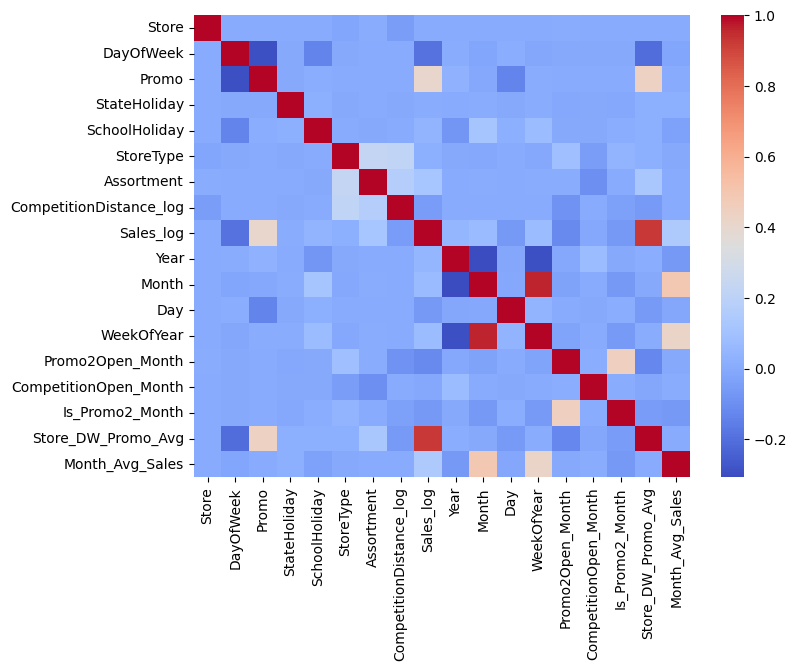

In [215]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(train_set.corr(), cmap='coolwarm')




In [216]:
# Thêm vào sau phần Feature Engineering của bạn
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

# Định nghĩa các model muốn thử nghiệm
models = {
    'BaselineLR': LinearRegression(),
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror', tree_method='hist', random_state=42)
    # ,
    # 'LightGBM': lgb.LGBMRegressor(objective='regression', random_state=42, verbose=-1),
    # 'CatBoost': CatBoostRegressor(loss_function='RMSE', logging_level='Silent', random_state=42)
}

# Định nghĩa lưới tham số (Grid) để GridSearchCV tìm kiếm
# Lưu ý: Với Rossmann, đừng để grid quá rộng vì dữ liệu rất lớn
model_grids = {
    'BaselineLR': {},
    'XGBoost': {
        'learning_rate': [0.02484904299575523],#0.02484904299575523
        'max_depth': [11],#ban đầu là 11
        'subsample': [0.8437880308889292],
        'colsample_bytree': [0.7688520150734801],
        'min_child_weight': [10,15,20,30],
        'gamma': [0.00023429788475798095],
        'n_estimators': [1000]
    }
    # ,
    # 'LightGBM': {
    #     'n_estimators': [500, 1000],
    #     'learning_rate': [0.05, 0.1],
    #     'num_leaves': [31, 64], # Tham số quan trọng nhất của LightGBM thay cho max_depth
    #     'feature_fraction': [0.8, 0.9]
    # },
    # 'CatBoost': {
    #     'iterations': [500],
    #     'learning_rate': [0.05, 0.1],
    #     'depth': [6, 10],
    #     'l2_leaf_reg': [1, 3, 5]
    # }
}

In [217]:
# Tạo hàm để tính RMSPE
def rmspe(y_true, y_pred):
    return np.sqrt(np.mean(((y_true - y_pred) / y_true)**2))

In [218]:
from sklearn.model_selection import GridSearchCV
import numpy as np

def evaluate_model_rossmann(name, model, grid, X_train, y_train, X_val, y_val):
    # 1. Huấn luyện mô hình
    if grid:
        # Sử dụng GridSearchCV để tìm tham số tốt nhất
        clf = GridSearchCV(model, grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
        clf.fit(X_train, y_train)
        best_model = clf.best_estimator_
        best_params = clf.best_params_
    else:
        best_model = model
        best_model.fit(X_train, y_train)
        best_params = best_model.get_params()

    # 2. Dự đoán cho cả tập Train và Val (đưa ngược về dạng exp)
    y_train_pred = np.exp(best_model.predict(X_train))
    y_val_pred = np.exp(best_model.predict(X_val))
    
    y_train_true = np.exp(y_train)
    y_val_true = np.exp(y_val)

    # 3. Tính toán RMSPE và Gap (Giống cell cũ của bạn)
    train_rmspe = rmspe(y_train_true, y_train_pred)
    val_rmspe = rmspe(y_val_true, y_val_pred)
    rmspe_gap = val_rmspe - train_rmspe
    
    # In kết quả nhanh để theo dõi
    print(f"[{name}] Train: {train_rmspe:.4f} | Val: {val_rmspe:.4f} | Gap: {rmspe_gap:.4f}")
    
    # 4. Trả về kết quả đầy đủ
    return {
        'train_rmspe': train_rmspe,
        'val_rmspe': val_rmspe,
        'rmspe_gap': rmspe_gap,
        'model': best_model,
        'params': best_params
    }

In [219]:
import mlflow
import mlflow.sklearn
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Thiết lập MLflow
mlflow.set_tracking_uri("http://127.0.0.1:5000/")
mlflow.set_experiment("Rossmann_Sales_Forecasting")

results = {}

with mlflow.start_run(run_name="Model_Comparison_Suite"):
    for name, model in models.items():
        print(f"Đang thực hiện thí nghiệm cho: {name}...")
        
        with mlflow.start_run(run_name=name, nested=True):
            # --- BƯỚC 1: CHẠY ĐÁNH GIÁ ---
            evaluation = evaluate_model_rossmann(name, model, model_grids[name], X_train, y_train, X_val, y_val)
            results[name] = evaluation
            best_model = evaluation['model']

            # --- BƯỚC 2: LOG METRICS & PARAMS ---
            mlflow.log_params(evaluation['params'])
            mlflow.log_metric("train_rmspe", evaluation['train_rmspe'])
            mlflow.log_metric("val_rmspe", evaluation['val_rmspe'])
            mlflow.log_metric("rmspe_gap", evaluation['rmspe_gap'])

            # --- BƯỚC 3: DỰ ĐOÁN ĐỂ VẼ RESIDUAL PLOT ---
            y_val_pred_log = best_model.predict(X_val)
            y_val_pred = np.exp(y_val_pred_log)
            y_val_orig = np.exp(y_val)
            residuals = y_val_orig - y_val_pred

            # --- BƯỚC 4: FEATURE IMPORTANCE (Linh hoạt cho từng loại model) ---
            plt.figure(figsize=(10, 8))
            try:
                if 'XGBoost' in name:
                    import xgboost as xgb
                    xgb.plot_importance(best_model, max_num_features=15, importance_type='gain', ax=plt.gca())
                elif 'LightGBM' in name:
                    import lightgbm as lgb
                    lgb.plot_importance(best_model, max_num_features=15, importance_type='gain', ax=plt.gca())
                elif 'CatBoost' in name:
                    feat_imp = pd.Series(best_model.get_feature_importance(), index=X_train.columns).sort_values(ascending=False).head(15)
                    feat_imp.plot(kind='barh', ax=plt.gca())
                else: # Cho Baseline (Linear Regression)
                    coefs = pd.Series(np.abs(best_model.coef_), index=X_train.columns).sort_values(ascending=False).head(15)
                    coefs.plot(kind='barh', ax=plt.gca())
                
                plt.title(f"Top 15 Features - {name}")
                plt.tight_layout()
                plt.savefig(f"feat_imp_{name}.png")
                mlflow.log_artifact(f"feat_imp_{name}.png")
            except Exception as e:
                print(f"Không thể vẽ Feature Importance cho {name}: {e}")
            plt.close()

            # --- BƯỚC 5: RESIDUAL ANALYSIS (Giống bản cũ của Đa) ---
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
            
            # Scatter Plot: Predicted vs Residuals
            sns.scatterplot(x=y_val_pred, y=residuals, ax=ax1, alpha=0.3)
            ax1.axhline(y=0, color='r', linestyle='--')
            ax1.set_title(f"Predicted vs Residuals - {name}")
            
            # Histogram: Residuals Distribution
            sns.histplot(residuals, kde=True, ax=ax2)
            ax2.set_title(f"Residuals Distribution - {name}")
            
            plt.tight_layout()
            plt.savefig(f"residuals_{name}.png")
            mlflow.log_artifact(f"residuals_{name}.png")
            plt.close()

            # --- BƯỚC 6: LƯU MODEL ---
            mlflow.sklearn.log_model(best_model, artifact_path=name.lower().replace(" ", "_"))
            
            print(f"{name} hoàn tất. Val RMSPE: {evaluation['val_rmspe']:.4f}")

print("\nTất cả thí nghiệm đã hoàn thành! Bạn hãy kiểm tra MLflow UI để xem biểu đồ chi tiết.")

Đang thực hiện thí nghiệm cho: BaselineLR...
[BaselineLR] Train: 0.2164 | Val: 0.1573 | Gap: -0.0591


2026/04/16 10:37:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/16 10:37:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


BaselineLR hoàn tất. Val RMSPE: 0.1573
🏃 View run BaselineLR at: http://127.0.0.1:5000/#/experiments/1/runs/0b413246e20a4215b9f0e892359113cc
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Đang thực hiện thí nghiệm cho: XGBoost...
[XGBoost] Train: 0.1149 | Val: 0.1202 | Gap: 0.0053


2026/04/16 10:42:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/16 10:42:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost hoàn tất. Val RMSPE: 0.1202
🏃 View run XGBoost at: http://127.0.0.1:5000/#/experiments/1/runs/d5683b6e30414fe1a75d393185fb8a0a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
🏃 View run Model_Comparison_Suite at: http://127.0.0.1:5000/#/experiments/1/runs/d2e3d0dea623415d972f8fe39adcd41f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1

Tất cả thí nghiệm đã hoàn thành! Bạn hãy kiểm tra MLflow UI để xem biểu đồ chi tiết.


In [220]:
print("gn-angqg-qg)

SyntaxError: unterminated string literal (detected at line 1) (1411696867.py, line 1)

In [ ]:
f

🚀 Đang thực hiện thí nghiệm cho: BaselineLR...


2026/04/16 09:16:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[BaselineLR] Train: 0.4706 | Val: 0.4028 | Gap: -0.0677


2026/04/16 09:16:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ BaselineLR hoàn tất. Val RMSPE: 0.4028 | Gap: -0.0677
🏃 View run BaselineLR at: http://127.0.0.1:5000/#/experiments/1/runs/baf18efcaf0149a2b80270104e18a307
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
🚀 Đang thực hiện thí nghiệm cho: XGBoost...


2026/04/16 09:19:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/16 09:19:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[XGBoost] Train: 0.1363 | Val: 0.1336 | Gap: -0.0027
✅ XGBoost hoàn tất. Val RMSPE: 0.1336 | Gap: -0.0027
🏃 View run XGBoost at: http://127.0.0.1:5000/#/experiments/1/runs/b22cdfb81ef44e7094d57ee951d196f4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
🏃 View run Model_Comparison_Suite at: http://127.0.0.1:5000/#/experiments/1/runs/d61682229b8941c3ba31bc31920798b7
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


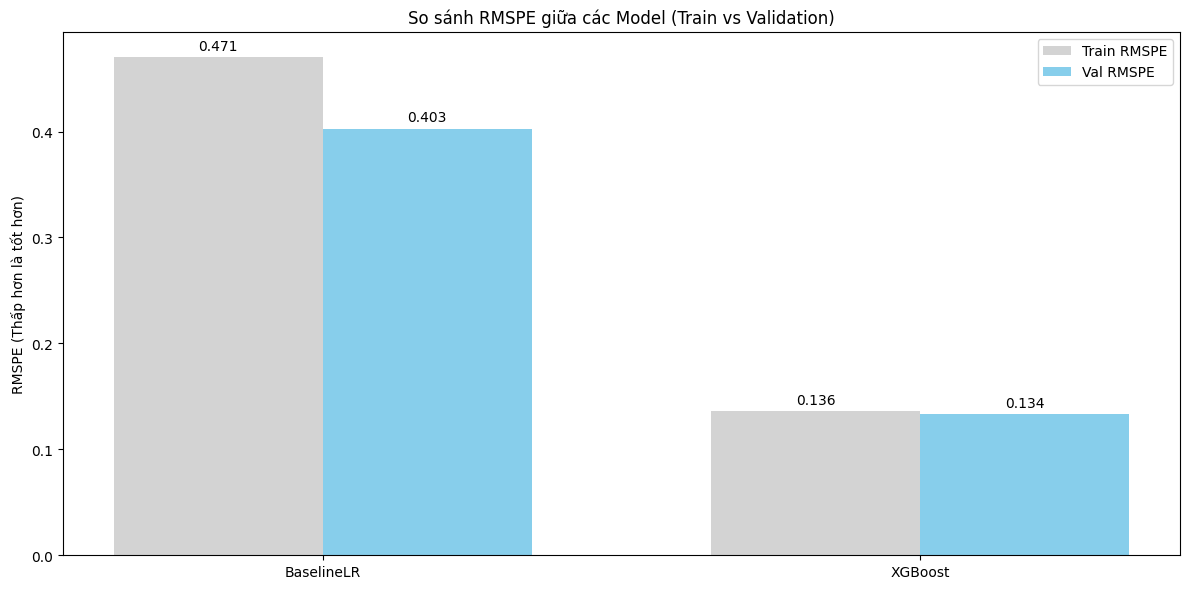

In [ ]:
import mlflow
import mlflow.sklearn

# Đảm bảo URI và Experiment trùng khớp với cấu hình hệ thống của bạn
mlflow.set_tracking_uri("http://127.0.0.1:5000/")
mlflow.set_experiment("Rossmann_Sales_Forecasting")

results = {}

with mlflow.start_run(run_name="Model_Comparison_Suite"):
    for name, model in models.items():
        print(f"🚀 Đang thực hiện thí nghiệm cho: {name}...")
        
        with mlflow.start_run(run_name=name, nested=True):
            # 1. Chạy đánh giá (Hàm này giờ trả về train_rmspe, val_rmspe, rmspe_gap)
            evaluation = evaluate_model_rossmann(name, model, model_grids[name], X_train, y_train, X_val, y_val)
            results[name] = evaluation

            # 2. Log các thông số và toàn bộ metrics lên MLflow
            mlflow.log_params(evaluation['params'])
            mlflow.log_metric("train_rmspe", evaluation['train_rmspe'])
            mlflow.log_metric("val_rmspe", evaluation['val_rmspe'])
            mlflow.log_metric("rmspe_gap", evaluation['rmspe_gap'])
            
            # 3. Lưu model artifact
            # Lưu ý: Nếu dùng LightGBM/CatBoost, MLflow vẫn có thể log qua sklearn wrapper 
            # nhưng tốt nhất nên dùng mlflow.models.log_model hoặc autolog đã setup trước đó.
            mlflow.sklearn.log_model(evaluation['model'], artifact_path=name.lower().replace(" ", "_"))
            
            print(f"✅ {name} hoàn tất. Val RMSPE: {evaluation['val_rmspe']:.4f} | Gap: {evaluation['rmspe_gap']:.4f}")

# --- PHẦN VẼ BIỂU ĐỒ SO SÁNH ---
import matplotlib.pyplot as plt
import numpy as np

names = list(results.keys())
train_values = [results[name]['train_rmspe'] for name in names]
val_values = [results[name]['val_rmspe'] for name in names]

x = np.arange(len(names))  # Vị trí các cột
width = 0.35  # Độ rộng cột

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, train_values, width, label='Train RMSPE', color='lightgrey')
rects2 = ax.bar(x + width/2, val_values, width, label='Val RMSPE', color='skyblue')

# Thêm văn bản, tiêu đề và nhãn
ax.set_ylabel('RMSPE (Thấp hơn là tốt hơn)')
ax.set_title('So sánh RMSPE giữa các Model (Train vs Validation)')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.legend()

# Gắn nhãn số liệu trên đầu mỗi cột
ax.bar_label(rects1, padding=3, fmt='%.3f')
ax.bar_label(rects2, padding=3, fmt='%.3f')

fig.tight_layout()
plt.show()

NotFittedError: need to call fit or load_model beforehand

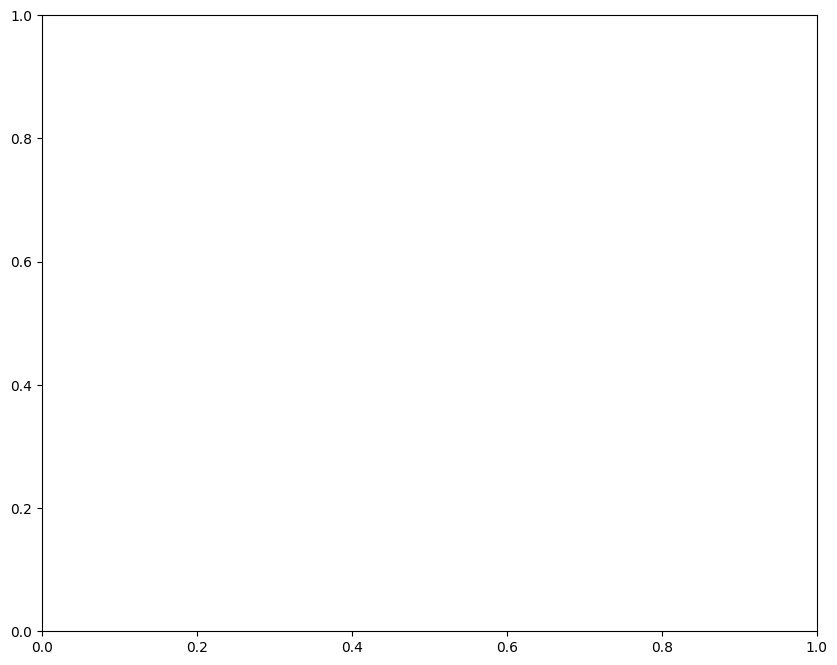

In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Vẽ biểu đồ quan trọng nhất: GAIN
# Gain cho biết feature đó đóng góp bao nhiêu vào việc giảm sai số
fig, ax = plt.subplots(figsize=(10, 8))
plot_importance(model, importance_type='gain', ax=ax, max_num_features=15)
plt.title("Feature Importance - GAIN (Sức mạnh thực tế)")
plt.show()

In [ ]:
import yaml
import os

# 1. Tìm model tốt nhất (Dựa trên kết quả Validation RMSPE thấp nhất)
# Sửa 'rmspe' thành 'val_rmspe' ở dòng dưới đây
best_model_name = min(results, key=lambda x: results[x]['val_rmspe'])
best_info = results[best_model_name]

# 2. Tạo dictionary cấu hình
model_config = {
    'project': 'Rossmann Store Sales',
    'best_model': {
        'name': best_model_name,
        'val_rmspe': float(best_info['val_rmspe']), # Cập nhật tên key
        'train_rmspe': float(best_info['train_rmspe']), # Lưu thêm thông tin chẩn đoán
        'params': best_info['params']
    },
    'features': {
        'input_columns': list(X_train.columns),
        'target': 'Sales_log'
    }
}

# 3. Lưu vào thư mục configs
config_path = '../configs/model_config.yaml'
os.makedirs(os.path.dirname(config_path), exist_ok=True)

with open(config_path, 'w') as f:
    yaml.dump(model_config, f, default_flow_style=False)

print(f"📦 Đã lưu cấu hình của model tốt nhất ({best_model_name}) tại: {config_path}")

📦 Đã lưu cấu hình của model tốt nhất (XGBoost) tại: ../configs/model_config.yaml
